# Comprehensive Exercise on Segmentation Analysis - Solution

**Spoiler:  
This notebook contains a comprehensive step-by-step solution to the exercise.  
Try working through the exercise on your own first before looking at this suggested solution.**

One extremely helpful application of Machine Learning is in data exploration and segementation analysis. Clustering algorithms help us find fundamental structures in data that is unknown to us, e.g., whether individual data points have any similarities that we do not yet recognize.

Let's try this out on a dataset about demographics, health metrics, and engagement patterns of patients.

We will use the [Patient Segmentation Dataset](https://www.kaggle.com/datasets/nudratabbas/patient-segmentation-data) from Kaggle (CC0: Public Domain).

The dataset contains 2000 patient records with comprehensive information including:
* Demographics like age, gender, geographic location
* Health metrics like height, weight, chronic conditions
* Healthcare utilization like annual visit frequency
* Insurance & engagement like insurance type, preventive care participation flag

The goal is to apply clustering on the patient data for a so-called Segmentation Analysis for identifying distinct patient personas (e.g., "High-risk seniors", "Young healthy adults", "Chronic disease patients").

**Your tasks:**
* Load the data from the file [patient_segmentation_dataset.csv](patient_segmentation_dataset.csv)
* Inspect the data and make yourself familiar with its content, data types, distributions, etc.
* Decide for a fitting clustering algorithm based on your data insights (e.g., can KMeans be used for this specific data?)
* Prepare the data for clustering and apply the clustering algorithm. Compare different clustering algorithms.
* Explore the clusters (patient segments) to gain helpful insights

In [1]:
# Import bia-bob as a helpful Python & Medical AI expert
from bia_bob import bob
import os

bob.initialize(
    endpoint='https://kiara.sc.uni-leipzig.de/api/v1', 
    model="vllm-llama-4-scout-17b-16e-instruct",
    system_prompt=os.getenv('SYSTEM_PROMPT_MEDICAL_AI')
)

In [2]:
%bob Who are you? Just one sentence!

I'm an expert in medical data science and a skilled Python programmer and data analyst with extensive experience working with various medical datasets and applying data analysis, machine learning, and deep learning techniques.

## Analysis Plan

We approach this analysis in structured steps:

1. **Load & inspect the data**: understand shape, types, distributions, and data quality
2. **Exploratory Data Analysis (EDA)**: visualize distributions and relationships
3. **Feature selection & preprocessing**: decide which features to use and how to prepare them, encode categoricals, scale numerics
4. **Algorithm selection and cluster profiling**: apply and compare different clustering algorithms, profile each cluster to identify patient personas
5. **Visualize and compare clusters**: use dimensionality reduction (PCA, t-SNE) for 2D visualization
8. **Wrap-up**: summarize findings and discuss limitations

## Step 1: Load and Inspect the Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the dataset
# Notes:
# - set PatientID as dataframe index: index_col=[colum index]
# - convert columns with dates to datatime format: parse_dates=[colum index]
# - prevents pandas from interpreting the string "None" as a missing value (NaN): keep_default_na=False
df = pd.read_csv('patient_segmentation_dataset.csv', sep=',', index_col=[0], parse_dates=[13], keep_default_na=False)

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 2000 entries, P10000 to P11999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Age                     2000 non-null   int64         
 1   Gender                  2000 non-null   str           
 2   State                   2000 non-null   str           
 3   City                    2000 non-null   str           
 4   Height_cm               2000 non-null   int64         
 5   Weight_kg               2000 non-null   int64         
 6   BMI                     2000 non-null   float64       
 7   Insurance_Type          2000 non-null   str           
 8   Primary_Condition       2000 non-null   str           
 9   Num_Chronic_Conditions  2000 non-null   int64         
 10  Annual_Visits           2000 non-null   int64         
 11  Avg_Billing_Amount      2000 non-null   float64       
 12  Last_Visit_Date         2000 non-null   datetime64[us]
 1

In [6]:
df.head(10)

,Age,Gender,State,City,Height_cm,Weight_kg,BMI,Insurance_Type,Primary_Condition,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Last_Visit_Date,Days_Since_Last_Visit,Preventive_Care_Flag
PatientID,,,,,,,,,,,,,,,
P10000,64,Male,GA,Unknown,151,115,50.4,Private,Arthritis,3,7,2995.0,2025-07-18,186,0
P10001,59,Male,OH,Unknown,189,68,19.0,Medicare,Depression,1,8,1209.0,2025-12-12,39,0
P10002,58,Female,PA,Unknown,156,91,37.4,Private,Asthma,1,4,999.0,2025-09-16,126,0
P10003,43,Female,GA,Unknown,152,92,39.8,Medicare,Hypertension,1,6,5638.5,2025-04-09,286,1
P10004,53,Female,NC,Unknown,167,51,18.3,Medicaid,Asthma,1,4,5796.0,2025-03-07,319,0
P10005,73,Male,OH,Unknown,160,120,46.9,Medicare,Anxiety,3,9,2397.5,2025-05-13,252,1
P10006,34,Male,PA,Unknown,161,51,19.7,Private,None,0,3,4668.0,2025-06-11,223,1
P10007,64,Female,MI,Unknown,177,102,32.6,Private,Arthritis,3,1,9942.5,2025-05-13,252,0
P10008,61,Female,PA,Unknown,171,86,29.4,Private,Arthritis,2,7,1036.0,2025-05-14,251,1


In [7]:
# Summary statistics for numeric columns
df.describe(include=['int64', 'float64']).T

,count,mean,std,min,25%,50%,75%,max
Age,2000.0,50.69550,15.444450,18.0,40.0,51.00,63.250,87.0
Height_cm,2000.0,167.90750,12.684494,145.0,158.0,168.00,177.000,195.0
Weight_kg,2000.0,85.14350,20.385428,50.0,67.0,86.00,103.000,120.0
BMI,2000.0,30.74065,8.839952,13.4,23.8,30.10,37.025,57.1
Num_Chronic_Conditions,2000.0,1.08000,0.890504,0.0,1.0,1.00,1.000,3.0
Annual_Visits,2000.0,5.46650,3.485965,1.0,3.0,4.00,8.000,12.0
Avg_Billing_Amount,2000.0,4000.27050,2463.239215,207.0,2061.0,3707.25,5650.875,12467.5
Days_Since_Last_Visit,2000.0,180.08500,104.688484,1.0,90.0,183.00,268.000,365.0
Preventive_Care_Flag,2000.0,0.46400,0.498827,0.0,0.0,0.00,1.000,1.0


In [8]:
# Summary statistics for categorical columns
df.describe(include='str').T

,count,unique,top,freq
Gender,2000,2,Female,1001
State,2000,10,NC,213
City,2000,20,Unknown,1012
Insurance_Type,2000,4,Medicare,906
Primary_Condition,2000,10,None,495


### Observations from Data Inspection

* **No missing values**
* **Mixed data types**: We have numerical features (Age, BMI, Avg_Billing_Amount, ...), categorical features (Gender, Insurance_Type, Primary_Condition), and binary features (Preventive_Care_Flag).
* **Columns to potentially exclude from clustering**: `Patient_ID` (unique identifier), `State` / `City` (high cardinality, many 'Unknown'), `Last_Visit_Date` (high cardinality, redundant with `Days_Since_Last_Visit`).
* The string `"None"` in `Primary_Condition` represents patients without a chronic condition. This is a valid category, not a missing value.

In [9]:
# Collect numerical feature names
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
print('Numerical features:\n', list(numerical_features))

# Collect categorical feature names
categorical_features = [feat for feat in df.select_dtypes(include=['str']).columns if feat not in ['State', 'City']]
print('Categorical features:\n', list(categorical_features))

Numerical features:
 ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Num_Chronic_Conditions', 'Annual_Visits', 'Avg_Billing_Amount', 'Days_Since_Last_Visit', 'Preventive_Care_Flag']
Categorical features:
 ['Gender', 'Insurance_Type', 'Primary_Condition']


## Step 2: Exploratory Data Analysis (EDA)

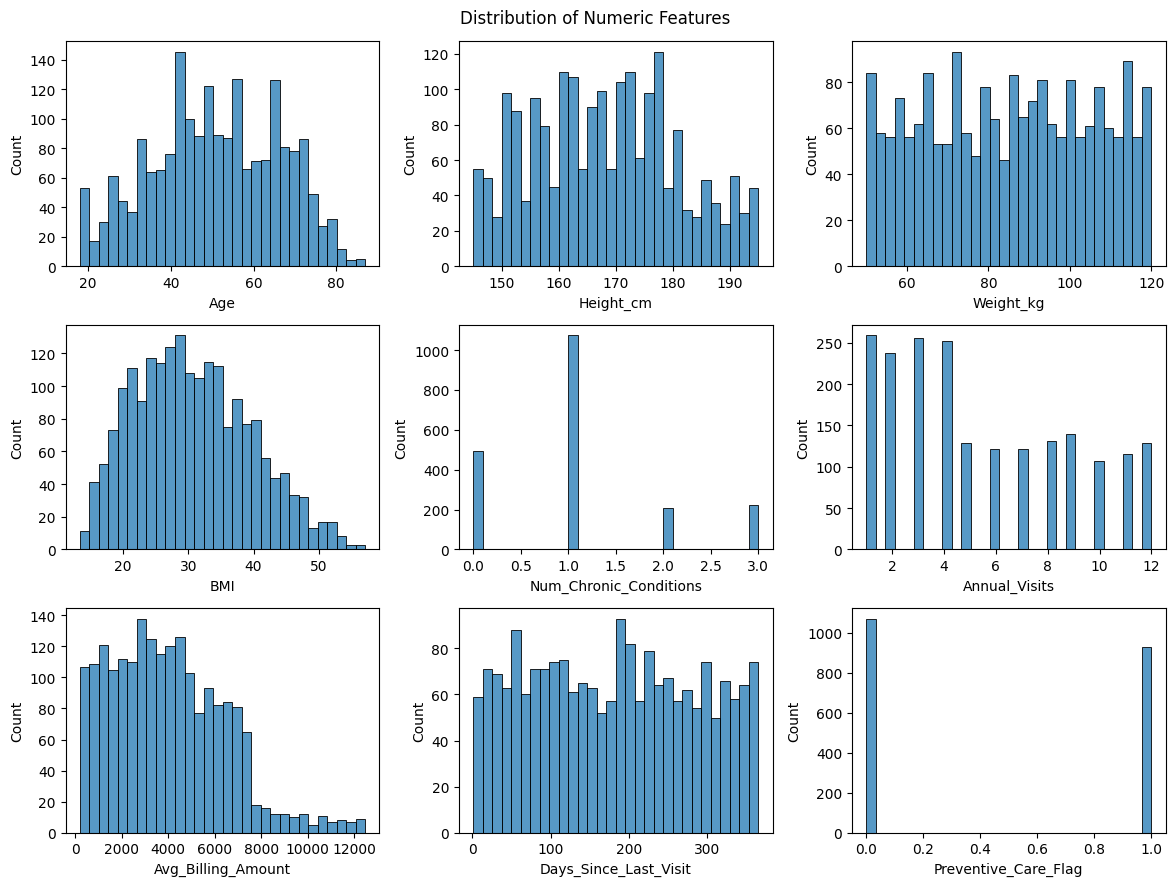

In [10]:
# Distribution of numerical features using histogram plots
fig, axes = plt.subplots(3, 3, figsize=(12, 9))

for ax, col in zip(axes.flatten(), numerical_features):
    sns.histplot(data=df, x=col, bins=30, ax=ax)

plt.suptitle('Distribution of Numeric Features', fontsize=12)
plt.tight_layout()
plt.show()

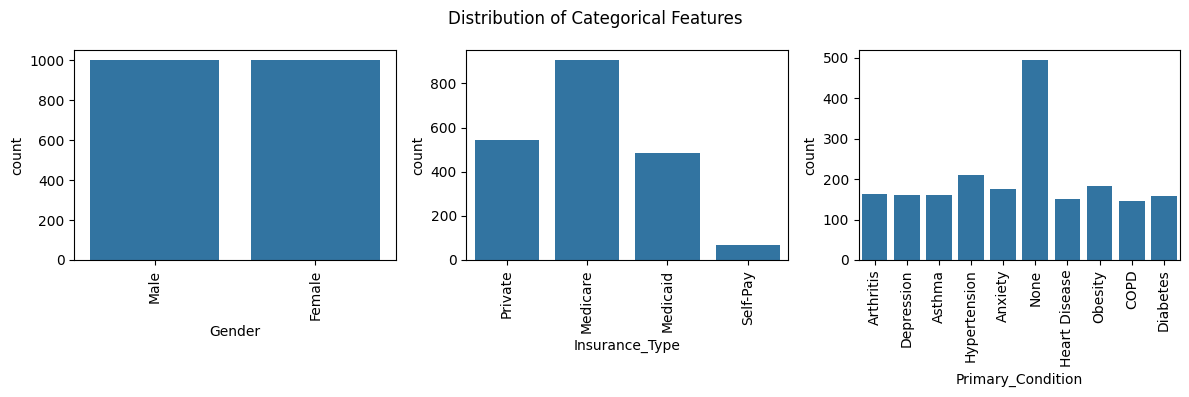

In [11]:
# Distribution of numerical features using count plots
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, col in zip(axes.flatten(), categorical_features):
    sns.countplot(data=df, x=col, ax=ax)
    ax.tick_params(axis='x', rotation=90)

plt.suptitle('Distribution of Categorical Features', fontsize=12)
plt.tight_layout()
plt.show()

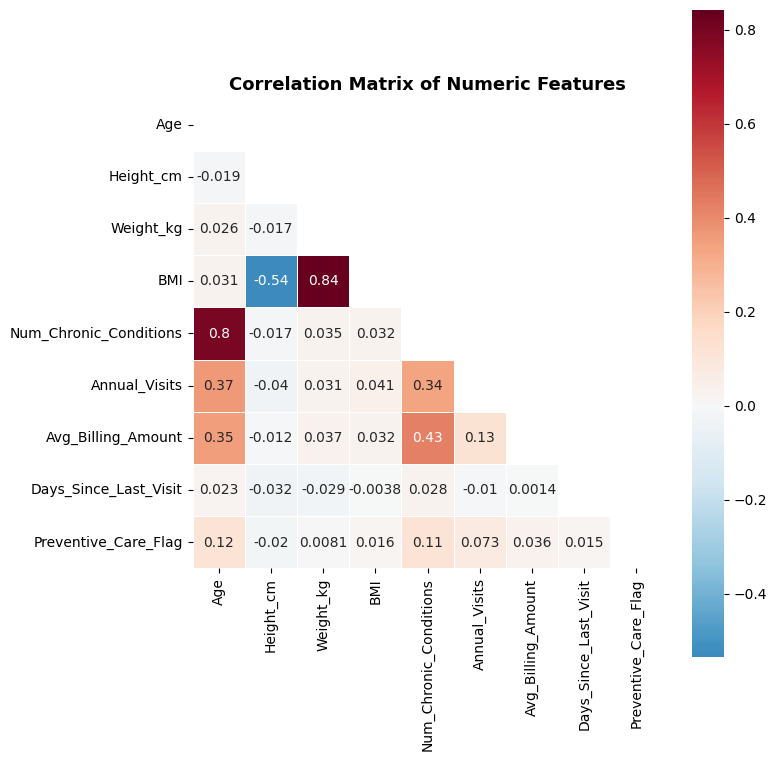

In [12]:
# Correlation matrix for numerical features
fig, ax = plt.subplots(figsize=(8, 8))

corr = df[numerical_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', center=0, square=True, linewidths=0.5, ax=ax)

ax.set_title('Correlation Matrix of Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

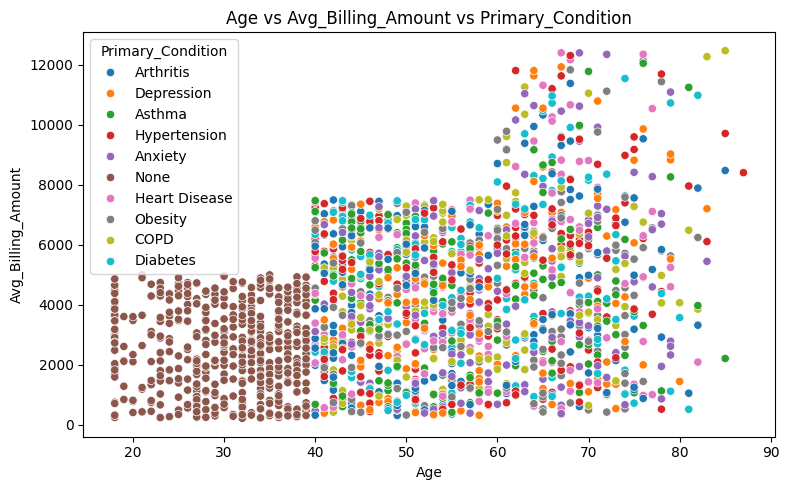

In [13]:
# Plot relationships: Age vs. Annual Cost, colored by Primary Condition
fig, axes = plt.subplots(figsize=(8, 5))

sns.scatterplot(data=df, x='Age', y='Avg_Billing_Amount', hue='Primary_Condition', ax=axes)
axes.set_title('Age vs Avg_Billing_Amount vs Primary_Condition')

plt.tight_layout()
plt.show()

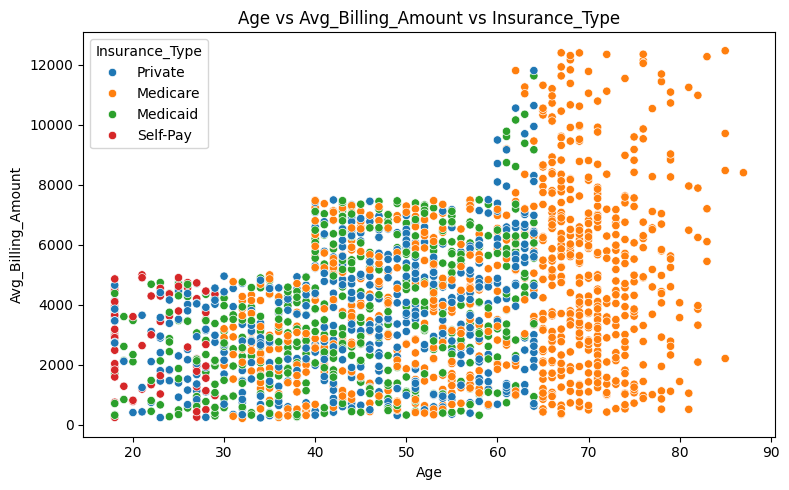

In [14]:
# Plot relationships: Age vs. Annual Cost, colored by Insurance Type
fig, axes = plt.subplots(figsize=(8, 5))

sns.scatterplot(data=df, x='Age', y='Avg_Billing_Amount', hue='Insurance_Type', ax=axes)
axes.set_title('Age vs Avg_Billing_Amount vs Insurance_Type')

plt.tight_layout()
plt.show()

### Key EDA Insights

* **Age** and **Gender** are roughly uniformly distributed
* **Age**, **Num_Chronic_Conditions**, **Anual_Visits**, and **Avg_Billing_Amount** are positively correlated – older patients visit more, have primary conditions, and cost more.
* **BMI** is derived from Height and Weight, so including all three would introduce redundancy. We should consider dropping Height and Weight, or BMI.
* Patients under 40 do not report any primary condition
* Younger patients under the age of 30 are more likely to pay out of pocket, while patients over the age of 65 are insured exclusively through Medicare.

## Step 3: Feature Selection and Preprocessing

### Feature decisions

**Include:**
* `Age` – key demographic
* `BMI` – derived health metric (we drop `Height_cm` and `Weight_kg` to avoid redundancy)
* `Num_Chronic_Conditions` – health complexity indicator
* `Annual_Visits` – healthcare utilization
* `Avg_Billing_Amount` – healthcare expenditure
* `Days_Since_Last_Visit` – recency of engagement
* `Preventive_Care_Flag` – engagement indicator (binary categorical with 0 / 1)
* `Gender` – key demographic (categorical, should be one-hot encoded)
* `Insurance_Type` – access indicator (categorical, should be one-hot encoded)
* `Primary_Condition` – health status (categorical, should be one-hot encoded)

**Exclude:**
* `Patient_ID` – identifier, not a feature
* `State`, `City` – high cardinality geographic data with many unknowns
* `Last_Visit_Date` – redundant with `Days_Since_Last_Visit`
* `Height_cm`, `Weight_kg` – redundant with `BMI`

In [15]:
# Select features for clustering
# Remove 'Height_cm' and 'Weight_kg' from numeric features
numerical_features_clustering = [feat for feat in numerical_features if feat not in ['Height_cm', 'Weight_kg']]
categorical_features_clustering = categorical_features

# Create a subset with selected features
df_features = df[numerical_features_clustering + categorical_features_clustering].copy()
print(f"Selected features for clustering: {len(df_features.columns)} columns")
df_features.head()

Selected features for clustering: 10 columns


,Age,BMI,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Days_Since_Last_Visit,Preventive_Care_Flag,Gender,Insurance_Type,Primary_Condition
PatientID,,,,,,,,,,
P10000,64,50.4,3,7,2995.0,186,0,Male,Private,Arthritis
P10001,59,19.0,1,8,1209.0,39,0,Male,Medicare,Depression
P10002,58,37.4,1,4,999.0,126,0,Female,Private,Asthma
P10003,43,39.8,1,6,5638.5,286,1,Female,Medicare,Hypertension
P10004,53,18.3,1,4,5796.0,319,0,Female,Medicaid,Asthma


In [16]:
# One-hot encoding for categorical features
df_encoded = pd.get_dummies(df_features, columns=categorical_features_clustering, drop_first=False)

print(f"Shape after encoding: {df_encoded.shape}")
print(f"\nEncoded feature names:")
for i, col in enumerate(df_encoded.columns):
    print(f"  {i+1:2d}. {col}")

df_encoded.head()

Shape after encoding: (2000, 23)

Encoded feature names:
   1. Age
   2. BMI
   3. Num_Chronic_Conditions
   4. Annual_Visits
   5. Avg_Billing_Amount
   6. Days_Since_Last_Visit
   7. Preventive_Care_Flag
   8. Gender_Female
   9. Gender_Male
  10. Insurance_Type_Medicaid
  11. Insurance_Type_Medicare
  12. Insurance_Type_Private
  13. Insurance_Type_Self-Pay
  14. Primary_Condition_Anxiety
  15. Primary_Condition_Arthritis
  16. Primary_Condition_Asthma
  17. Primary_Condition_COPD
  18. Primary_Condition_Depression
  19. Primary_Condition_Diabetes
  20. Primary_Condition_Heart Disease
  21. Primary_Condition_Hypertension
  22. Primary_Condition_None
  23. Primary_Condition_Obesity


,Age,BMI,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Days_Since_Last_Visit,Preventive_Care_Flag,Gender_Female,Gender_Male,Insurance_Type_Medicaid,...,Primary_Condition_Anxiety,Primary_Condition_Arthritis,Primary_Condition_Asthma,Primary_Condition_COPD,Primary_Condition_Depression,Primary_Condition_Diabetes,Primary_Condition_Heart Disease,Primary_Condition_Hypertension,Primary_Condition_None,Primary_Condition_Obesity
PatientID,,,,,,,,,,,,,,,,,,,,,
P10000,64,50.4,3,7,2995.0,186,0,False,True,False,...,False,True,False,False,False,False,False,False,False,False
P10001,59,19.0,1,8,1209.0,39,0,False,True,False,...,False,False,False,False,True,False,False,False,False,False
P10002,58,37.4,1,4,999.0,126,0,True,False,False,...,False,False,True,False,False,False,False,False,False,False
P10003,43,39.8,1,6,5638.5,286,1,True,False,False,...,False,False,False,False,False,False,False,True,False,False
P10004,53,18.3,1,4,5796.0,319,0,True,False,True,...,False,False,True,False,False,False,False,False,False,False


### Why Scaling?

Some clustering algorithms use distances, e.g. KMeans uses Euclidean distance. Without scaling, features with large ranges (e.g., `Avg_Billing_Amount`) would dominate the distance calculation over features with small ranges (e.g., `Preventive_Care_Flag` being 0 or 1). StandardScaler transforms each feature to have mean=0 and std=1, giving all features equal influence.

In [17]:
# Standardize all features 
from sklearn.preprocessing import StandardScaler

print("Statistics of first 5 features before scaling:\n", 
      df_encoded.iloc[:, :5].describe().T[['mean', 'std']].round(4))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

print("\nStatistics of first 5 features after scaling:\n", 
      pd.DataFrame(X_scaled, columns=df_encoded.columns).iloc[:, :5].describe().T[['mean', 'std']].round(4))

Statistics of first 5 features before scaling:
                              mean        std
Age                       50.6955    15.4445
BMI                       30.7406     8.8400
Num_Chronic_Conditions     1.0800     0.8905
Annual_Visits              5.4665     3.4860
Avg_Billing_Amount      4000.2705  2463.2392

Statistics of first 5 features after scaling:
                         mean     std
Age                     -0.0  1.0003
BMI                     -0.0  1.0003
Num_Chronic_Conditions  -0.0  1.0003
Annual_Visits           -0.0  1.0003
Avg_Billing_Amount      -0.0  1.0003


## Step 4: Algorithm Selection

### Overview of Clustering Algorithms

We apply and compare three clustering algorithms from scikit-learn on the same preprocessed and scaled patient data:

| Algorithm | Type | Requires K? | Handles Noise? | Shape Assumption | Key Hyperparameter(s) |
|-----------|------|-------------|----------------|------------------|-----------------------|
| **KMeans** | Centroid-based | Yes | No - all points assigned | Spherical, equal-size | `n_clusters` |
| **DBSCAN** | Density-based | Auto-discovered | Yes - noise labeled -1 | Arbitrary | `eps`, `min_samples` |
| **MeanShift** | Kernel density-based | Auto-discovered | No - all points assigned | Arbitrary | `bandwidth` |

**How each algorithm works:**

- **KMeans**: Assigns each point to the nearest centroid and iterates until convergence. Fast and interpretable, but requires specifying K and assumes convex, equally-sized clusters, and euclidean feature space.
- **DBSCAN**: Identifies clusters as dense regions separated by sparser areas. Points in low-density zones are labeled *noise*. Powerful for irregularly shaped clusters, but sensitive to `eps` and `min_samples`.
- **MeanShift**: Shifts a kernel window towards local density maxima. Discovers K automatically based on data density. The `bandwidth` parameter controls kernel size.

**The following steps on clustering are:**
* Step 4.1: KMeans
  * Elbow method + silhouette analysis to select K
  * Fit KMeans with K
  * Numeric profile table + detailed per-cluster summaries + heatmap
* Step 4.2: DBSCAN
  * k-distance plot for eps selection
  * Fit DBSCAN
  * Numeric profile table + detailed per-cluster summaries + heatmap
* Step 4.3: MeanShift
  * Bandwidth estimation with estimate_bandwidth
  * Fit MeanShift
  * Numeric profile table + detailed per-cluster summaries + heatmap
* Step 5 - Side-by-side comparison
  * PCA projection (1×3 subplots: KMeans | DBSCAN | MeanShift), with KMeans cluster centers marked
  * t-SNE projection (same layout)
  * Quantitative metrics table (Silhouette, Davies-Bouldin, Inertia)

After fitting all three algorithms, we compare their results using **PCA** and **t-SNE** projections in Step 5.

Here, we define some more methods for further cluster analysis:

In [18]:
profile_cols = ['Age', 'BMI', 'Num_Chronic_Conditions', 'Annual_Visits', 'Avg_Billing_Amount', 'Days_Since_Last_Visit']

# Method for printing descriptive statistics for a specified cluster algorithm
def print_cluster_profile(clustering='Cluster_KMeans'):
    cluster_profile = df.groupby(clustering)[profile_cols].agg(['mean', 'std']).round(2)
    display(cluster_profile)

# Method for printing aggregated statistics for a specified cluster algorithm and cluster number
def print_cluster_statistics(clustering='Cluster_KMeans', cluster_nb=0):
    grp = df[df[clustering] == cluster_nb]
    n = len(grp)
    print(f"\n{'='*70}")
    print(f"  CLUSTER {cluster_nb}  (n={n}, {n/len(df)*100:.1f}% of patients)")
    print(f"{'='*70}")
    print(f"  Age:                {grp['Age'].mean():.1f} ± {grp['Age'].std():.1f}")
    print(f"  BMI:                {grp['BMI'].mean():.1f} ± {grp['BMI'].std():.1f}")
    print(f"  Chronic conditions: {grp['Num_Chronic_Conditions'].mean():.2f} (avg)")
    top_cond = grp['Primary_Condition'].value_counts().head(3)
    print(f"  Top conditions:     {', '.join([f'{cd} ({ct})' for cd, ct in top_cond.items()])}")
    print(f"  Annual visits:      {grp['Annual_Visits'].mean():.1f}")
    print(f"  Avg billing:        ${grp['Avg_Billing_Amount'].mean():,.0f}")
    print(f"  Preventive care:    {grp['Preventive_Care_Flag'].mean()*100:.1f}%")
    gender_pct = grp['Gender'].value_counts(normalize=True) * 100
    print(f"  Gender:             {', '.join([f'{g}: {p:.0f}%' for g, p in gender_pct.items()])}")
    ins_pct = grp['Insurance_Type'].value_counts(normalize=True) * 100
    print(f"  Insurance:          {', '.join([f'{t}: {p:.0f}%' for t, p in ins_pct.items()])}")

# Method for visualizing cluster means
def plot_cluster_means_heatmap(clustering='Cluster_KMeans'):
    cluster_means = df.groupby(clustering)[profile_cols].mean()
    norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(norm.T, annot=cluster_means.T.round(1).values, fmt='', annot_kws={"size": 8},
                cmap='YlOrRd', linewidths=1, ax=ax, cbar_kws={'label': 'Normalized value'})
    ax.set_xlabel(clustering, fontsize=10)
    ax.set_title('Cluster Profiles Comparison\n(numbers = actual means, color = normalized)', fontsize=12,)
    plt.tight_layout()
    plt.show()

## Step 4.1: KMeans

KMeans partitions data into K clusters by minimizing within-cluster variance (inertia). Each point is assigned to its nearest centroid; centroids are updated iteratively until convergence.

**Assumptions:**
- All features are numeric and on a comparable scale (met via StandardScaler)
- Clusters are roughly spherical and similarly sized
- K must be specified in advance, we determine it with the methods below

### Determine the Optimal Number of Clusters

We use two complementary methods:
1. **Elbow Method** - plot inertia (within-cluster sum of squares) vs. K; look for the "elbow" where gains diminish
2. **Silhouette Score** - measures how well each point fits its own cluster vs. its nearest neighbor cluster (range −1 to 1, higher is better)

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 15)
inertias = []
silhouette_scores_kmeans = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores_kmeans.append(sil)
    print(f"K={k:2d}  |  Inertia: {km.inertia_:10.0f}  |  Silhouette: {sil:.4f}")

K= 2  |  Inertia:      40206  |  Silhouette: 0.1179
K= 3  |  Inertia:      37111  |  Silhouette: 0.1254
K= 4  |  Inertia:      35237  |  Silhouette: 0.1463
K= 5  |  Inertia:      33327  |  Silhouette: 0.1509
K= 6  |  Inertia:      31437  |  Silhouette: 0.2034
K= 7  |  Inertia:      29238  |  Silhouette: 0.2301
K= 8  |  Inertia:      27051  |  Silhouette: 0.2536
K= 9  |  Inertia:      24850  |  Silhouette: 0.2829
K=10  |  Inertia:      22943  |  Silhouette: 0.2929
K=11  |  Inertia:      21646  |  Silhouette: 0.2675
K=12  |  Inertia:      19959  |  Silhouette: 0.2702
K=13  |  Inertia:      19342  |  Silhouette: 0.2678
K=14  |  Inertia:      18996  |  Silhouette: 0.2578


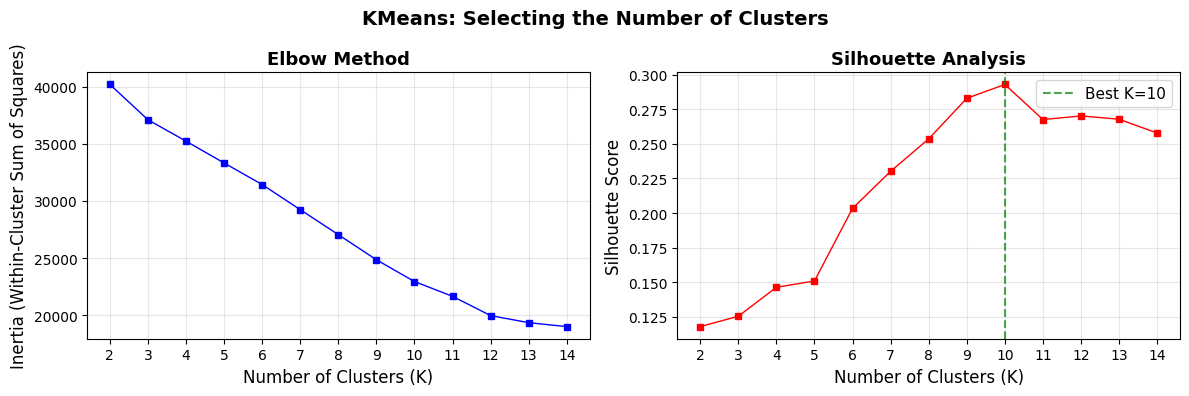


Best K by Silhouette Score: 10 (score: 0.2929)


In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Elbow plot
ax1.plot(list(K_range), inertias, 'bs-', linewidth=1, markersize=4)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
ax1.set_title('Elbow Method', fontsize=13, fontweight='bold')
ax1.set_xticks(list(K_range))
ax1.grid(True, alpha=0.3)

# Silhouette plot
ax2.plot(list(K_range), silhouette_scores_kmeans, 'rs-', linewidth=1, markersize=4)
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Analysis', fontsize=13, fontweight='bold')
ax2.set_xticks(list(K_range))
ax2.grid(True, alpha=0.3)

best_k = list(K_range)[np.argmax(silhouette_scores_kmeans)]
ax2.axvline(x=best_k, color='green', linestyle='--', alpha=0.7, label=f'Best K={best_k}')
ax2.legend(fontsize=11)

plt.suptitle('KMeans: Selecting the Number of Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nBest K by Silhouette Score: {best_k} (score: {max(silhouette_scores_kmeans):.4f})")

### Choosing K

The silhouette scores are relatively low overall. This is common for real-world, high-dimensional, mixed-type data. 
The elbow plot unfortunatelly shows no noticeable flattening.

**In practice, domain knowledge should also inform the final choice of K.**

**We choose K=6** as a practical balance:
* Shows the first big bump in silhouette score
* Provides enough granularity to identify distinct patient personas
* Keeps segments manageable for clinical interpretation
* Consistent with healthcare domain expectations (3–6 personas are typical)

### Fit KMeans with K

In [21]:
K = 6

kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)
df['Cluster_KMeans'] = kmeans_labels

print(f"KMeans (K={K}) – Cluster sizes:")
print(df['Cluster_KMeans'].value_counts().sort_index())
print(f"\nSilhouette Score: {silhouette_score(X_scaled, kmeans_labels):.4f}")

KMeans (K=6) – Cluster sizes:
Cluster_KMeans
0    664
1    158
2    495
3    370
4    150
5    163
Name: count, dtype: int64

Silhouette Score: 0.2034


### Profile KMeans Clusters

We inspect the cluster profiles to understand the characteristics of each patient segment - looking at demographics, health metrics, and healthcare utilization.

In [22]:
# Print cluster profile
print_cluster_profile('Cluster_KMeans')

Age           BMI       Num_Chronic_Conditions        \
                 mean    std   mean   std                   mean   std   
Cluster_KMeans                                                           
0               57.64  11.18  30.97  8.97                   1.45  0.75   
1               56.37  10.79  31.85  7.86                   1.43  0.73   
2               30.40   6.39  29.89  8.83                   0.00  0.00   
3               57.32  10.97  31.47  9.08                   1.41  0.72   
4               58.35  10.77  30.14  8.47                   1.47  0.77   
5               56.45  11.74  30.21  8.85                   1.42  0.73   

               Annual_Visits       Avg_Billing_Amount           \
                        mean   std               mean      std   
Cluster_KMeans                                                   
0                       6.57  3.40            4420.68  2466.95   
1                       6.58  3.49            4679.84  2665.75   
2                       2.51  1.09            2598.31  1393.22   
3                       6.55  3.47            4526.89  2618.55   
4                       5.89  3.65            4428.27  2720.12   
5                       6.00  3.38            4297.17  2581.05   

               Days_Since_Last_Visit          
                                mean     std  
Cluster_KMeans                                
0                             177.27  106.92  
1                             198.32  102.21  
2                             173.49  103.66  
3                             181.07  104.42  
4                             177.96   99.78  
5                             193.61  104.36

In [23]:
# Print statistics for cluster n
print_cluster_statistics('Cluster_KMeans', 0)


  CLUSTER 0  (n=664, 33.2% of patients)
  Age:                57.6 ± 11.2
  BMI:                31.0 ± 9.0
  Chronic conditions: 1.45 (avg)
  Top conditions:     Obesity (183), Anxiety (175), Asthma (160)
  Annual visits:      6.6
  Avg billing:        $4,421
  Preventive care:    51.8%
  Gender:             Female: 51%, Male: 49%
  Insurance:          Medicare: 56%, Private: 25%, Medicaid: 18%


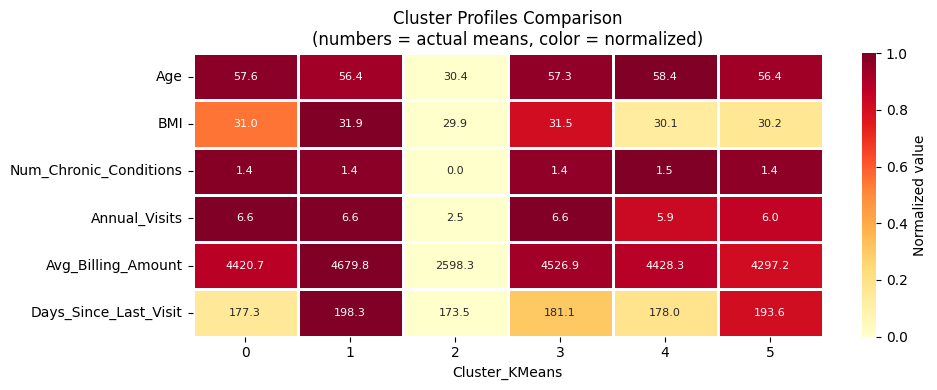

In [24]:
plot_cluster_means_heatmap('Cluster_KMeans')

## Step 4.2: DBSCAN

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) defines clusters as dense regions separated by sparser areas.

**Key properties:**
* No need to specify K, the number of clusters is discovered automatically
* Points in low-density regions are labeled as **noise (label = −1)** and excluded from clusters
* Can find clusters of arbitrary shape
* Sensitive to two hyperparameters:
  * `eps`: neighborhood radius - how far apart two points can be to be considered neighbors
  * `min_samples`: minimum number of neighbors for a point to be a *core point*

### Select `eps` with the k-Distance Plot

For each point, we compute the distance to its k-th nearest neighbor (where k = `min_samples`).  
Sorting and plotting these distances reveals an "elbow", the distance at the elbow is a good candidate for `eps`.

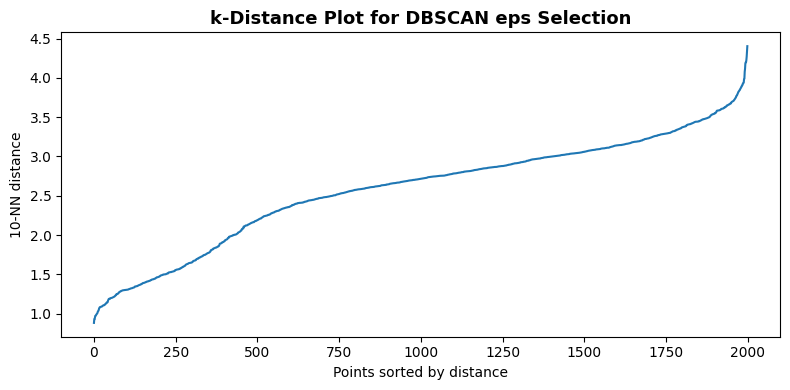

min_samples = 10
Suggested eps range (80th–90th percentile of k-distances): 3.14 – 3.37


In [25]:
from sklearn.neighbors import NearestNeighbors

min_samples_dbscan = 10

nbrs = NearestNeighbors(n_neighbors=min_samples_dbscan).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
sns.lineplot(x=np.arange(len(k_distances)), y=k_distances)
plt.xlabel('Points sorted by distance', fontsize=10)
plt.ylabel(f'{min_samples_dbscan}-NN distance', fontsize=10)
plt.title('k-Distance Plot for DBSCAN eps Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"min_samples = {min_samples_dbscan}")
print(f"Suggested eps range (80th–90th percentile of k-distances): "
      f"{np.percentile(k_distances, 80):.2f} – {np.percentile(k_distances, 90):.2f}")

### Fit DBSCAN

We set `eps` based on the elbow in the k-distance plot above. A value near the 80th–90th percentile of k-distances is a common starting point. Adjust `eps` up to merge clusters or down to split them.

In [26]:
from sklearn.cluster import DBSCAN

eps_dbscan = 3.5

dbscan = DBSCAN(eps=eps_dbscan, min_samples=min_samples_dbscan)
dbscan_labels = dbscan.fit_predict(X_scaled)
df['Cluster_DBSCAN'] = dbscan_labels

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = int((dbscan_labels == -1).sum())

print(f"DBSCAN (eps={eps_dbscan}, min_samples={min_samples_dbscan})")
print(f"Clusters found: {n_clusters_dbscan}")
print(f"Noise points:   {n_noise} ({n_noise / len(dbscan_labels) * 100:.1f}%)")
print(f"\nCluster sizes:")
for label in sorted(set(dbscan_labels)):
    count = (dbscan_labels == label).sum()
    name = f"Cluster {label}" if label != -1 else "Noise (-1)"
    print(f"  {name}: {count} ({count / len(dbscan_labels) * 100:.1f}%)")

mask_non_noise = dbscan_labels != -1
if n_clusters_dbscan > 1 and mask_non_noise.sum() > 1:
    sil_dbscan = silhouette_score(X_scaled[mask_non_noise], dbscan_labels[mask_non_noise])
    print(f"\nSilhouette Score (non-noise points): {sil_dbscan:.4f}")

DBSCAN (eps=3.5, min_samples=10)
Clusters found: 11
Noise points:   4 (0.2%)

Cluster sizes:
  Noise (-1): 4 (0.2%)
  Cluster 0: 158 (7.9%)
  Cluster 1: 160 (8.0%)
  Cluster 2: 210 (10.5%)
  Cluster 3: 174 (8.7%)
  Cluster 4: 429 (21.4%)
  Cluster 5: 163 (8.2%)
  Cluster 6: 150 (7.5%)
  Cluster 7: 183 (9.2%)
  Cluster 8: 145 (7.2%)
  Cluster 9: 66 (3.3%)
  Cluster 10: 158 (7.9%)

Silhouette Score (non-noise points): 0.3233


### Profile DBSCAN Clusters

We inspect the cluster profiles to understand the characteristics of each patient segment - looking at demographics, health metrics, and healthcare utilization.

In [27]:
# Print cluster profile
print_cluster_profile('Cluster_DBSCAN')

Age           BMI       Num_Chronic_Conditions        \
                 mean    std   mean   std                   mean   std   
Cluster_DBSCAN                                                           
-1              63.25   0.96  22.65  7.31                   3.00  0.00   
 0              57.54  10.63  31.72  8.77                   1.39  0.67   
 1              57.24  11.19  32.00  9.55                   1.41  0.72   
 2              57.09  11.28  31.35  9.31                   1.41  0.74   
 3              58.78  10.95  31.70  8.79                   1.47  0.77   
 4              31.54   5.92  29.82  8.81                   0.00  0.00   
 5              56.45  11.74  30.21  8.85                   1.42  0.73   
 6              58.35  10.77  30.14  8.47                   1.47  0.77   
 7              57.62  11.53  29.81  8.48                   1.48  0.76   
 8              56.66  11.07  30.58  8.98                   1.40  0.73   
 9              23.03   4.06  30.33  9.02                   0.00  0.00   
 10             56.37  10.79  31.85  7.86                   1.43  0.73   

               Annual_Visits       Avg_Billing_Amount           \
                        mean   std               mean      std   
Cluster_DBSCAN                                                   
-1                      4.25  5.19           10985.00   852.37   
 0                      6.77  3.29            4219.30  2559.14   
 1                      6.91  3.34            4341.62  2399.63   
 2                      6.43  3.59            4689.83  2567.73   
 3                      6.41  3.46            4537.60  2637.18   
 4                      2.46  1.10            2578.62  1381.46   
 5                      6.00  3.38            4297.17  2581.05   
 6                      5.89  3.65            4428.27  2720.12   
 7                      6.65  3.37            4193.49  2385.80   
 8                      6.30  3.38            4573.91  2351.09   
 9                      2.85  0.98            2726.32  1471.93   
 10                     6.58  3.49            4679.84  2665.75   

               Days_Since_Last_Visit          
                                mean     std  
Cluster_DBSCAN                                
-1                            171.75  150.51  
 0                            177.58  102.48  
 1                            183.83  103.24  
 2                            182.60  105.89  
 3                            176.84  112.69  
 4                            174.38  103.87  
 5                            193.61  104.36  
 6                            177.96   99.78  
 7                            175.57  103.49  
 8                            174.48  108.41  
 9                            167.76  102.86  
 10                           198.32  102.21

In [28]:
# Print statistics for cluster n
print_cluster_statistics('Cluster_DBSCAN', 0)


  CLUSTER 0  (n=158, 7.9% of patients)
  Age:                57.5 ± 10.6
  BMI:                31.7 ± 8.8
  Chronic conditions: 1.39 (avg)
  Top conditions:     Depression (158)
  Annual visits:      6.8
  Avg billing:        $4,219
  Preventive care:    48.1%
  Gender:             Female: 54%, Male: 46%
  Insurance:          Medicare: 46%, Medicaid: 27%, Private: 27%


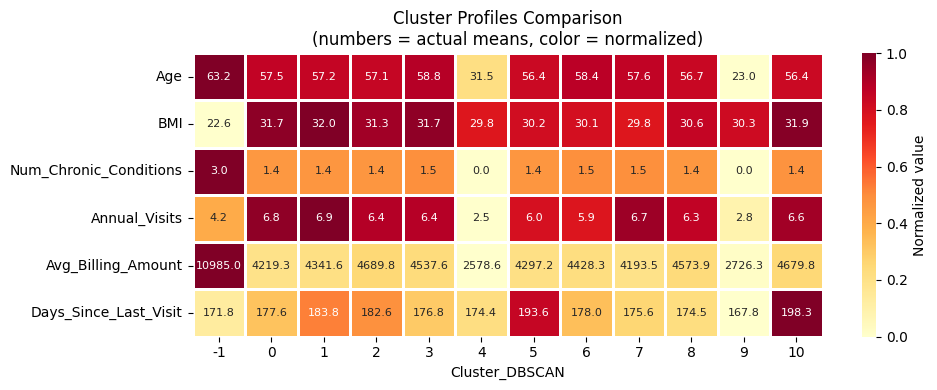

In [29]:
plot_cluster_means_heatmap('Cluster_DBSCAN')

### DBSCAN Results

**Why DBSCAN struggles here:** High-dimensional patient data (23 features after encoding) tends to have roughly uniform density across the feature space. There are no sharp density drop-offs between patient groups. DBSCAN excels when clusters visibly differ in local density (e.g., spatial or sensor data). Adjusting `eps` changes the result, but no clear multi-cluster structure emerges.

**Key observations:**
* DBSCAN finds very few meaningful clusters, decreasing `eps` tends to create lots of small clusters
* The noise percentage is sensitive to `eps`: increasing `eps` reduces noise but merges clusters
* This behavior is typical for dense, uniformly distributed tabular health data

## Step 4.3: MeanShift

**MeanShift** iteratively shifts each data point towards the local density maximum (mode) by averaging over all points within a kernel window. Points that converge to the same mode form a cluster.

**Key properties:**
* No need to specify K, the number of clusters is determined automatically by data density
* All points are assigned to a cluster (no explicit noise concept)
* The `bandwidth` parameter controls the kernel size:
  * Larger bandwidth: fewer, coarser clusters
  * Smaller bandwidth: more, finer clusters

### Estimate Bandwidth

The `estimate_bandwidth` function uses a nearest-neighbor heuristic to suggest a reasonable bandwidth. The `quantile` parameter (0–1) controls the fraction of pairwise distances used: lower values yield smaller bandwidth and more clusters.

In [30]:
from sklearn.cluster import MeanShift, estimate_bandwidth

# Estimate bandwidth on a random subset for speed
bandwidth = estimate_bandwidth(X_scaled, quantile=0.1, n_samples=1000, random_state=42)
print(f"Estimated bandwidth: {bandwidth:.4f}")
print(f"\nAdjust quantile to control cluster granularity:")
print(f"- Lower quantile -> smaller bandwidth -> more clusters")
print(f"- Higher quantile -> larger bandwidth -> fewer clusters")

Estimated bandwidth: 5.3331

Adjust quantile to control cluster granularity:
- Lower quantile -> smaller bandwidth -> more clusters
- Higher quantile -> larger bandwidth -> fewer clusters


### Fit MeanShift

In [31]:
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms_labels = ms.fit_predict(X_scaled)
df['Cluster_MeanShift'] = ms_labels

n_clusters_ms = len(set(ms_labels))
print(f"MeanShift (bandwidth={bandwidth:.4f})")
print(f"Clusters found: {n_clusters_ms}")
print(f"\nCluster sizes:")
for label in sorted(set(ms_labels)):
    count = (ms_labels == label).sum()
    print(f"  Cluster {label}: {count} ({count / len(ms_labels) * 100:.1f}%)")

if n_clusters_ms > 1:
    sil_ms = silhouette_score(X_scaled, ms_labels)
    print(f"\nSilhouette Score: {sil_ms:.4f}")

MeanShift (bandwidth=5.3331)
Clusters found: 2

Cluster sizes:
  Cluster 0: 1934 (96.7%)
  Cluster 1: 66 (3.3%)

Silhouette Score: 0.2212


### Profile MeanShift Clusters

We inspect the cluster profiles to understand the characteristics of each patient segment - looking at demographics, health metrics, and healthcare utilization.

In [32]:
# Print cluster profile
print_cluster_profile('Cluster_MeanShift')

Age           BMI       Num_Chronic_Conditions        \
                    mean    std   mean   std                   mean   std   
Cluster_MeanShift                                                           
0                  51.64  14.80  30.75  8.84                   1.12  0.88   
1                  23.03   4.06  30.33  9.02                   0.00  0.00   

                  Annual_Visits       Avg_Billing_Amount           \
                           mean   std               mean      std   
Cluster_MeanShift                                                   
0                          5.56  3.51            4043.75  2478.82   
1                          2.85  0.98            2726.32  1471.93   

                  Days_Since_Last_Visit          
                                   mean     std  
Cluster_MeanShift                                
0                                180.51  104.75  
1                                167.76  102.86

In [33]:
# Print statistics for cluster n
print_cluster_statistics('Cluster_MeanShift', 0)


  CLUSTER 0  (n=1934, 96.7% of patients)
  Age:                51.6 ± 14.8
  BMI:                30.8 ± 8.8
  Chronic conditions: 1.12 (avg)
  Top conditions:     None (429), Hypertension (210), Obesity (183)
  Annual visits:      5.6
  Avg billing:        $4,044
  Preventive care:    46.8%
  Gender:             Male: 50%, Female: 50%
  Insurance:          Medicare: 47%, Private: 28%, Medicaid: 25%


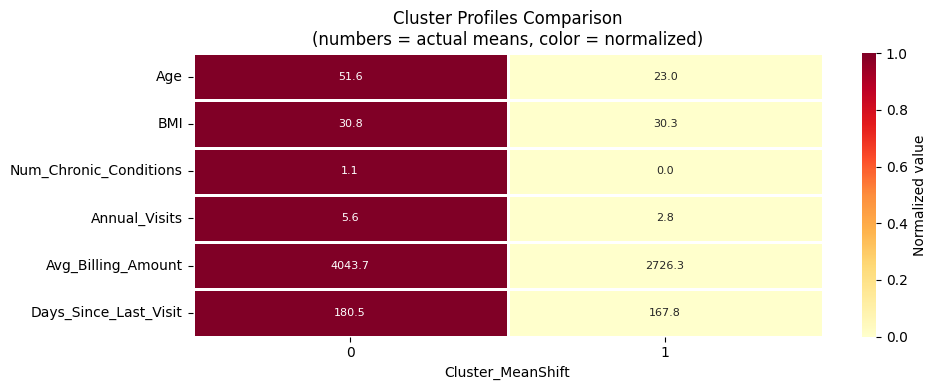

In [34]:
plot_cluster_means_heatmap('Cluster_MeanShift')

### MeanShift Results

MeanShift often yields a small number of clusters on this dataset because the patient data occupies a relatively compact, uniform region in high-dimensional space.  
The clusters found correspond to the dominant density modes.

**Observations:**
* The number of clusters is determined automatically based on data density
* Unlike DBSCAN, all patients are assigned to a cluster (no noise)
* The bandwidth parameter is the main tuning lever; `estimate_bandwidth` provides a data-driven starting point

## Step 5: Comparison of Clustering Algorithms

We now compare all three algorithms side-by-side using two dimensionality reduction techniques:

- **Step 5.1**: **PCA** - linear projection, preserves global variance structure, fast
- **Step 5.2**: **t-SNE** - non-linear projection, preserves local neighborhood structure, slower

Both projections are computed on the same scaled data `X_scaled` and colored by each algorithm's cluster labels.

### PCA Projection

In [35]:
from sklearn.decomposition import PCA

# Compute 2D PCA projection
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}% total  "
      f"(PC1: {pca.explained_variance_ratio_[0]*100:.1f}%,  "
      f"PC2: {pca.explained_variance_ratio_[1]*100:.1f}%)")

PCA explained variance: 25.0% total  (PC1: 16.1%,  PC2: 9.0%)


In [36]:
# Helper: scatter plot of cluster labels on 2D coordinates
def plot_clusters_2d(ax, X_2d, labels, title, xlabel='PC_1', ylabel='PC_2'):
    palette = plt.cm.tab10.colors
    for i, label in enumerate(sorted(set(labels))):
        mask = np.array(labels) == label
        color = 'lightgrey' if label == -1 else palette[i % len(palette)]
        lname = 'Noise' if label == -1 else f'Cluster {label}'
        mk = 'x' if label == -1 else 'o'
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=[color], label=lname, alpha=0.5, s=20,
                   marker=mk, linewidth=0.2)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='best', markerscale=1.5)

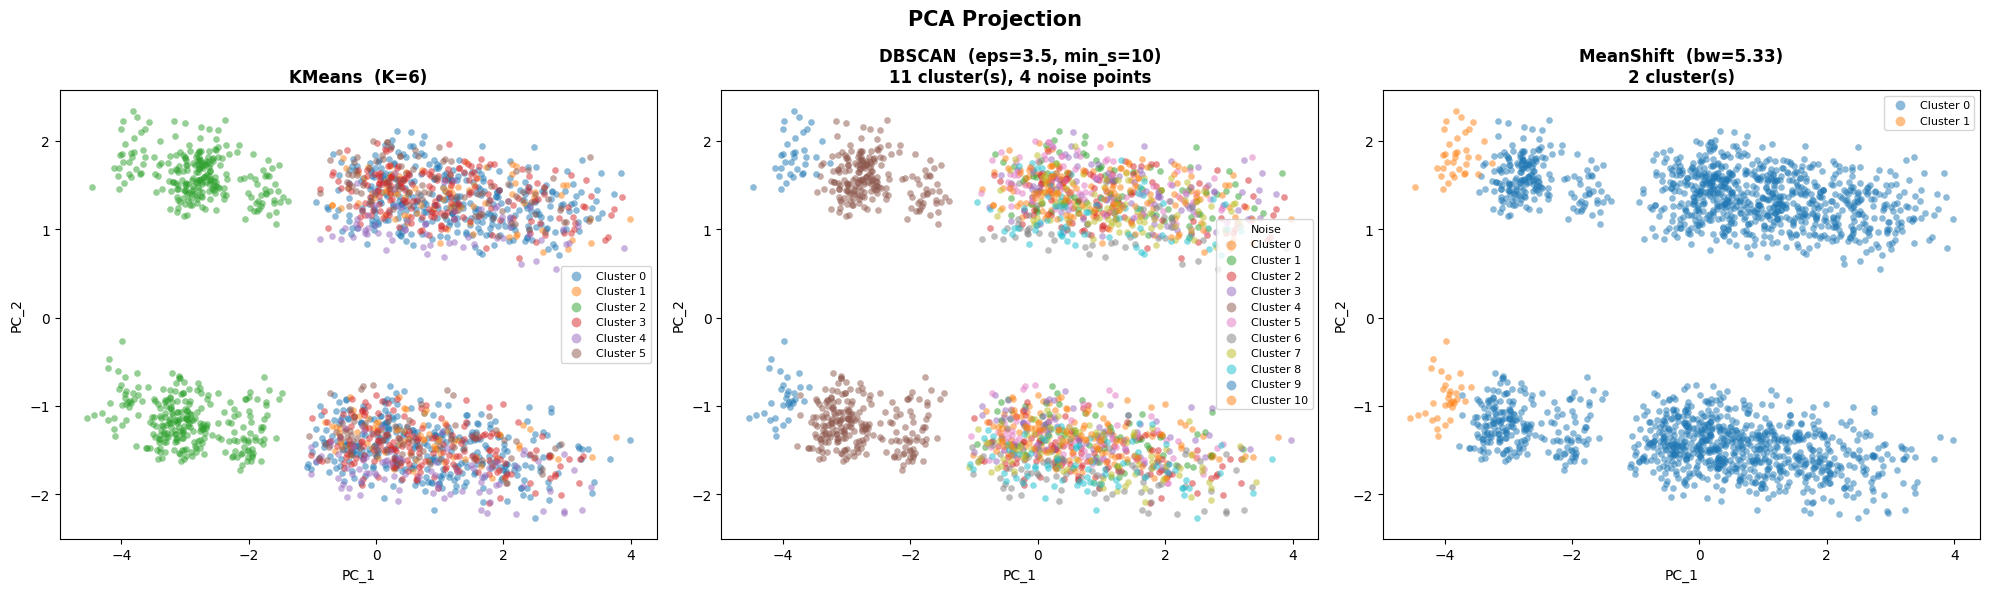

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# KMeans
plot_clusters_2d(ax=axes[0], X_2d=X_pca, labels=kmeans_labels,
                 title=f'KMeans  (K={K})')

# DBSCAN
n_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
plot_clusters_2d(ax=axes[1], X_2d=X_pca, labels=dbscan_labels,
                 title=f'DBSCAN  (eps={eps_dbscan}, min_s={min_samples_dbscan})\n'
                 f'{n_db} cluster(s), {n_noise} noise points')

# MeanShift
n_ms = len(set(ms_labels))
plot_clusters_2d(ax=axes[2], X_2d=X_pca, labels=ms_labels,
                 title=f'MeanShift  (bw={bandwidth:.2f})\n{n_ms} cluster(s)')

plt.suptitle('PCA Projection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### t-SNE Projection

**t-SNE** (t-distributed Stochastic Neighbor Embedding) is a non-linear technique that preserves local neighborhood structure, revealing fine-grained cluster topology that PCA may miss.

Key properties:
* Non-linear: better at revealing local cluster boundaries
* Stochastic: results depend on the random seed and `perplexity` (~5–50)
* Not suitable for projecting new points — purely a visualization tool
* **Interpretation**: nearby points in t-SNE space are locally similar, but distances between clusters are not directly meaningful

In [38]:
from sklearn.manifold import TSNE

print("Computing t-SNE (this may take a moment)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)
print("Done.")

Computing t-SNE (this may take a moment)...
Done.


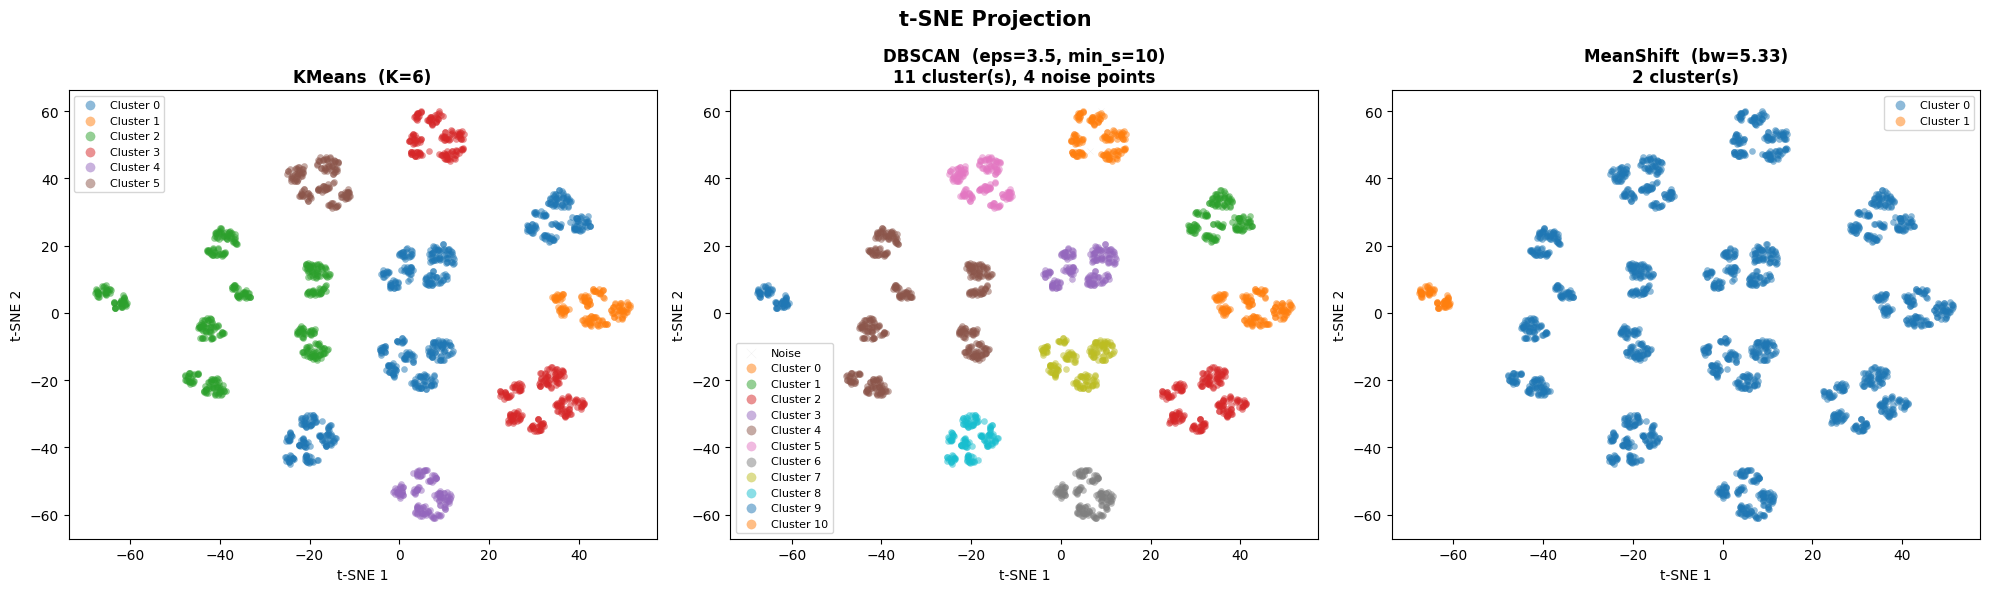

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

n_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_ms = len(set(ms_labels))

# KMeans
plot_clusters_2d(ax=axes[0], X_2d=X_tsne, labels=kmeans_labels,
                 title=f'KMeans  (K={K})', xlabel='t-SNE 1', ylabel='t-SNE 2')

# DBSCAN
plot_clusters_2d(ax=axes[1], X_2d=X_tsne, labels=dbscan_labels,
                 title=f'DBSCAN  (eps={eps_dbscan}, min_s={min_samples_dbscan})\n'
                 f'{n_db} cluster(s), {n_noise} noise points',
                 xlabel='t-SNE 1', ylabel='t-SNE 2')


plot_clusters_2d(ax=axes[2], X_2d=X_tsne, labels=ms_labels,
                 title=f'MeanShift  (bw={bandwidth:.2f})\n{n_ms} cluster(s)',
                 xlabel='t-SNE 1', ylabel='t-SNE 2')

plt.suptitle('t-SNE Projection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [42]:
from sklearn.metrics import davies_bouldin_score

results = {}

# KMeans
results['KMeans'] = {
    'n_clusters':      K,
    'n_noise':         0,
    'silhouette':      round(silhouette_score(X_scaled, kmeans_labels), 4),
    'davies_bouldin':  round(davies_bouldin_score(X_scaled, kmeans_labels), 4),
    'inertia':         round(kmeans_final.inertia_, 1),
}

# DBSCAN
mask_nn = dbscan_labels != -1
if n_clusters_dbscan > 1 and mask_nn.sum() > 1:
    sil_db = round(silhouette_score(X_scaled[mask_nn], dbscan_labels[mask_nn]), 4)
    dbi_db = round(davies_bouldin_score(X_scaled[mask_nn], dbscan_labels[mask_nn]), 4)
else:
    sil_db = float('nan')
    dbi_db = float('nan')

results['DBSCAN'] = {
    'n_clusters':     n_clusters_dbscan,
    'n_noise':        n_noise,
    'silhouette':     sil_db,
    'davies_bouldin': dbi_db,
    'inertia':        float('nan'),
}

# MeanShift
results['MeanShift'] = {
    'n_clusters':     n_clusters_ms,
    'n_noise':        0,
    'silhouette':     round(silhouette_score(X_scaled, ms_labels), 4) if n_clusters_ms > 1 else float('nan'),
    'davies_bouldin': round(davies_bouldin_score(X_scaled, ms_labels), 4) if n_clusters_ms > 1 else float('nan'),
    'inertia':        float('nan'),
}

df_metrics = pd.DataFrame(results).T
df_metrics.index.name = 'Algorithm'
print("Quantitative Metric Comparison\n")
print(df_metrics.to_string())
print("\nMetric interpretation:")
print("  Silhouette:     higher is better  (range: −1 to 1)")
print("  Davies-Bouldin: lower is better   (range: 0 to ∞)")
print("  Inertia:        lower is better   (KMeans only)")

Quantitative Metric Comparison

           n_clusters  n_noise  silhouette  davies_bouldin  inertia
Algorithm                                                          
KMeans            6.0      0.0      0.2034          2.2101  31437.0
DBSCAN           11.0      4.0      0.3233          1.3009      NaN
MeanShift         2.0      0.0      0.2212          1.0641      NaN

Metric interpretation:
  Silhouette:     higher is better  (range: −1 to 1)
  Davies-Bouldin: lower is better   (range: 0 to ∞)
  Inertia:        lower is better   (KMeans only)


## Step 6: Wrap-Up and Summary

### Algorithm Comparison Summary

| | KMeans | DBSCAN | MeanShift |
|---|---|---|---|
| **Clusters found** | 6 (specified) | Medium (auto) | Very Few (auto) |
| **Noise handling** | None, all points assigned | Labels outliers −1 | None, all points assigned |
| **Shape flexibility** | Spherical | Arbitrary | Arbitrary |
| **Main tuning lever** | K | `eps`, `min_samples` | `bandwidth` |
| **Best suited when** | K is known, compact clusters | Data has clear density contrasts | Data has clear density modes |

### Why KMeans Works Best Here

Patient data in high-dimensional, mixed-feature space tends to be **uniformly dense**.  
There are no sharp density drop-offs between patient groups. DBSCAN and MeanShift struggle in this setting because:
* DBSCAN requires density contrasts that simply don't exist in this tabular data
* MeanShift's automatic bandwidth estimation yields very few, coarse clusters

KMeans provides stable, interpretable segments despite its spherical-cluster assumption.

### Limitations

* **KMeans on one-hot data**: Euclidean distance on binary features is pragmatic but imperfect; K-Prototypes handles mixed types more naturally
* **K selection is ambiguous**: different K values yield different but potentially valid segmentations — always validate with domain experts
* **Geographic features excluded**: including location could reveal regional patterns
* **Synthetic data**: patterns may be clearer than in real clinical data

### Next Steps

* Validate clusters with clinical domain experts
* Try K-Prototypes (native mixed-type support) or hierarchical clustering with Gower distance
* Apply UMAP for non-linear dimensionality reduction before clustering
* Use cluster labels as features for downstream prediction tasks